It demonstrates:
**bold text**
Loading the 561-feature dataset

Train–test split

Training multiple models using Scikit-learn

Evaluation metrics (Accuracy, Precision, Recall, F1)

Visualization using Matplotlib and Seaborn

Confusion Matrix visualization

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns

Load UCI-HAR Dataset

Download dataset from:

https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones

After extracting the dataset folder:

In [2]:
from google.colab import drive
drive.mount('/content/drive')
#os.chdir("/content/drive/MyDrive")

Mounted at /content/drive


In [4]:
#After extracting the dataset folder:

X = pd.read_csv("/content/drive/MyDrive/VAT datasets/UCIHAR561/X_train.txt", sep=r"\s+", header=None)
y = pd.read_csv("/content/drive/MyDrive/VAT datasets/UCIHAR561/y_train.txt", header=None)

X_test = pd.read_csv("/content/drive/MyDrive/VAT datasets/UCIHAR561/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("/content/drive/MyDrive/VAT datasets/UCIHAR561/y_test.txt", header=None)

print(X.shape)

(7352, 561)


Meaning:

7352 samples

561 features

In [5]:
#Combine Train and Test Dataset
X = pd.concat([X, X_test])
y = pd.concat([y, y_test])

In [6]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
#Define Machine Learning Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [9]:
#Train Models and Evaluate
results = []

for name, model in models.items():

    model.fit(X_train, y_train.values.ravel())

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results,
                          columns=["Model","Accuracy","Precision","Recall","F1 Score"])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.983495,0.983632,0.983495,0.983488
1,Decision Tree,0.928641,0.929172,0.928641,0.928707
2,Random Forest,0.974272,0.974295,0.974272,0.974259
3,KNN,0.959709,0.960800,0.959709,0.959688
4,SVM,0.973301,0.973271,0.973301,0.973256


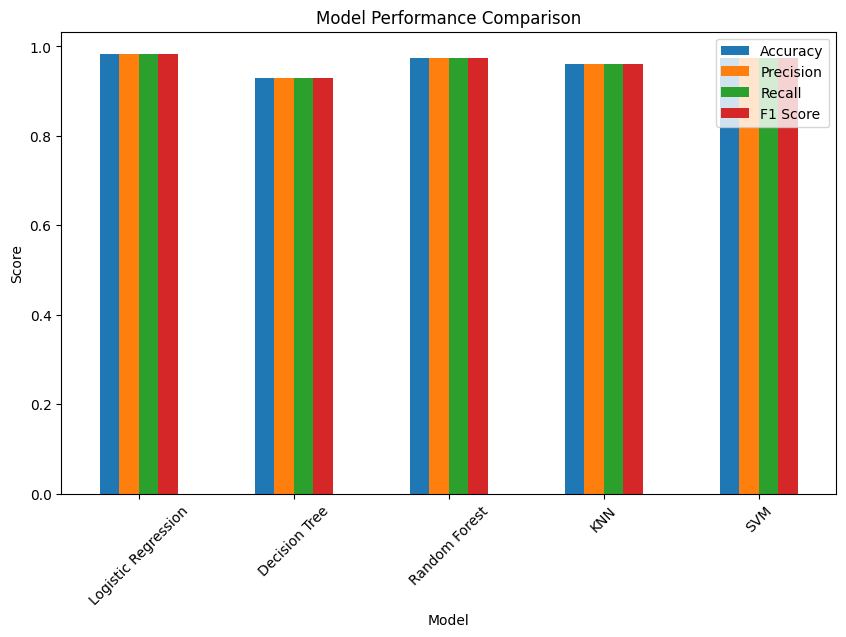

In [10]:
#Model Comparison Visualization
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(
    kind="bar", figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [11]:
#Confusion Matrix

#Example using Random Forest

model = RandomForestClassifier()
model.fit(X_train, y_train.values.ravel())

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

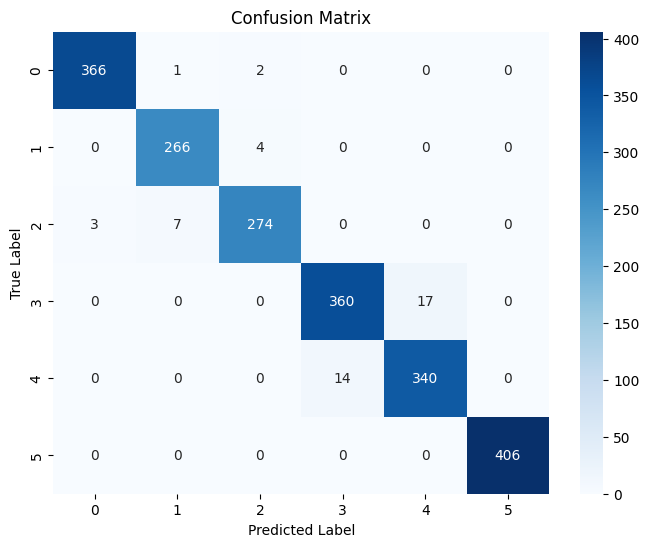

In [12]:
#Confusion Matrix Visualization
plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

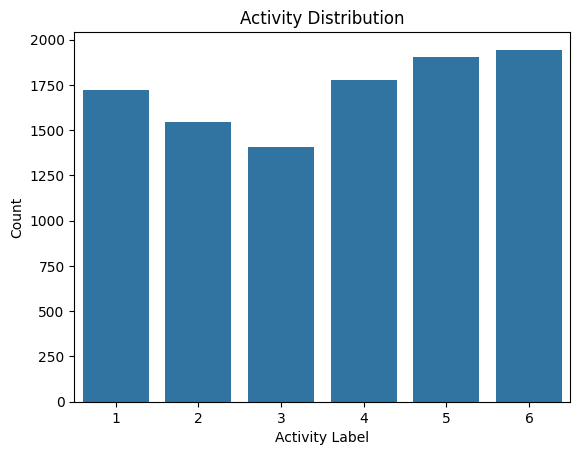

In [13]:
#Activity Distribution Visualization
sns.countplot(x=y[0])

plt.title("Activity Distribution")
plt.xlabel("Activity Label")
plt.ylabel("Count")

plt.show()

#This shows how balanced the dataset is.

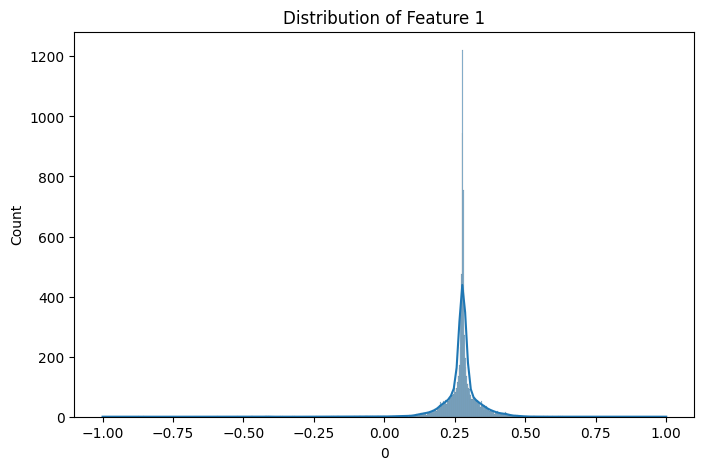

In [14]:
#Feature Distribution Example
plt.figure(figsize=(8,5))

sns.histplot(X[0], kde=True)

plt.title("Distribution of Feature 1")

plt.show()

#Students can explore how sensor features are distributed.

**ML Pipeline Summary**

UCI HAR Dataset

       ↓

Load Data (561 Features)

       ↓

Feature Scaling

       ↓

Train-Test Split

       ↓

Train ML Models

(LogReg, DT, RF, KNN, SVM)

       ↓

Evaluation Metrics

       ↓

Visualization


In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [16]:
X = pd.read_csv("/content/drive/MyDrive/VAT datasets/UCIHAR561/X_train.txt",
                delim_whitespace=True, header=None)

y = pd.read_csv("/content/drive/MyDrive/VAT datasets/UCIHAR561/y_train.txt",
                header=None)

/tmp/ipykernel_162/2917056127.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X = pd.read_csv("/content/drive/MyDrive/VAT datasets/UCIHAR561/X_train.txt",


In [17]:
#Check shape:

print(X.shape)

(7352, 561)


In [18]:
#Standardize the Features

#Scaling is important before PCA and t-SNE.
#μ = 0 and σ = 1

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
#PCA Visualization (Dimensionality Reduction)

#PCA reduces 561 features → 2 principal components.

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [20]:
#Create a DataFrame for plotting:

pca_df = pd.DataFrame()

pca_df["PC1"] = X_pca[:,0]
pca_df["PC2"] = X_pca[:,1]
pca_df["Activity"] = y[0]

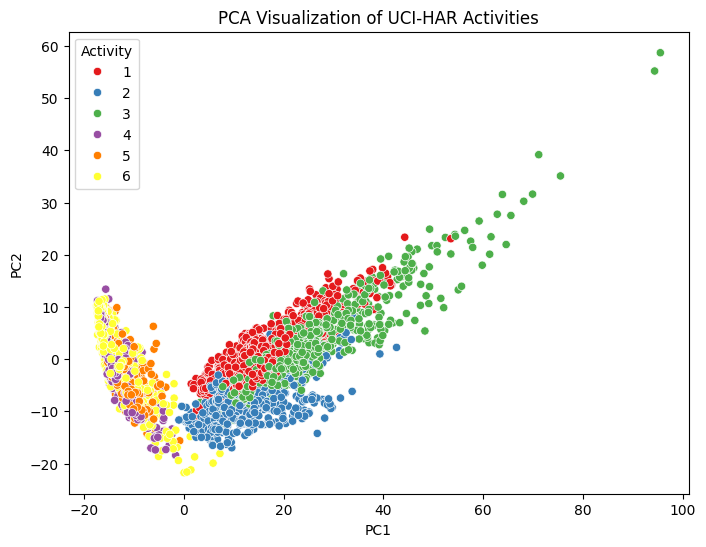

In [21]:
#PCA Scatter Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Activity",
    palette="Set1",
    data=pca_df
)

plt.title("PCA Visualization of UCI-HAR Activities")
#plt.savefig("pca.png")
plt.show()

In [22]:
#t-SNE Visualization

#t-SNE is better for visualizing complex high-dimensional data.

#It is slower than PCA.

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_scaled)

In [23]:
#Create dataframe:

tsne_df = pd.DataFrame()

tsne_df["Dim1"] = X_tsne[:,0]
tsne_df["Dim2"] = X_tsne[:,1]
tsne_df["Activity"] = y[0]

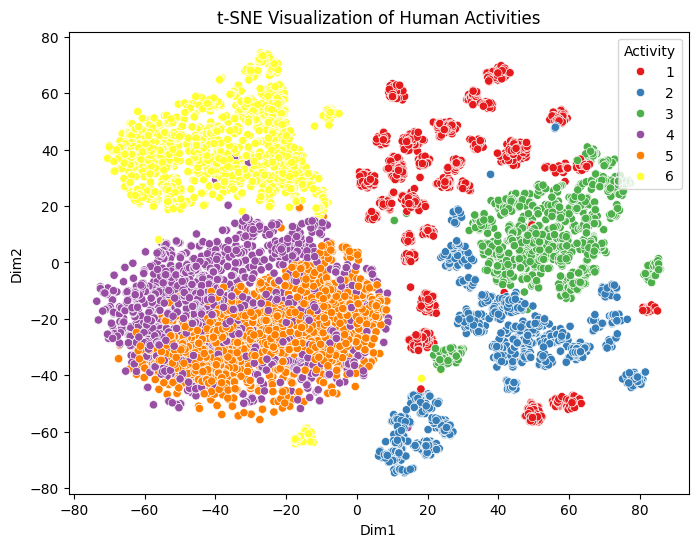

In [24]:
#t-SNE Plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Dim1",
    y="Dim2",
    hue="Activity",
    palette="Set1",
    data=tsne_df
)

plt.title("t-SNE Visualization of Human Activities")

plt.show()

In [25]:
#Better Activity Labels

#Replace numbers with activity names.

activity_map = {
1:"Walking",
2:"Walking Upstairs",
3:"Walking Downstairs",
4:"Sitting",
5:"Standing",
6:"Laying"
}

pca_df["Activity"] = pca_df["Activity"].map(activity_map)
tsne_df["Activity"] = tsne_df["Activity"].map(activity_map)

PCA → linear reduction

t-SNE → nonlinear manifold learning

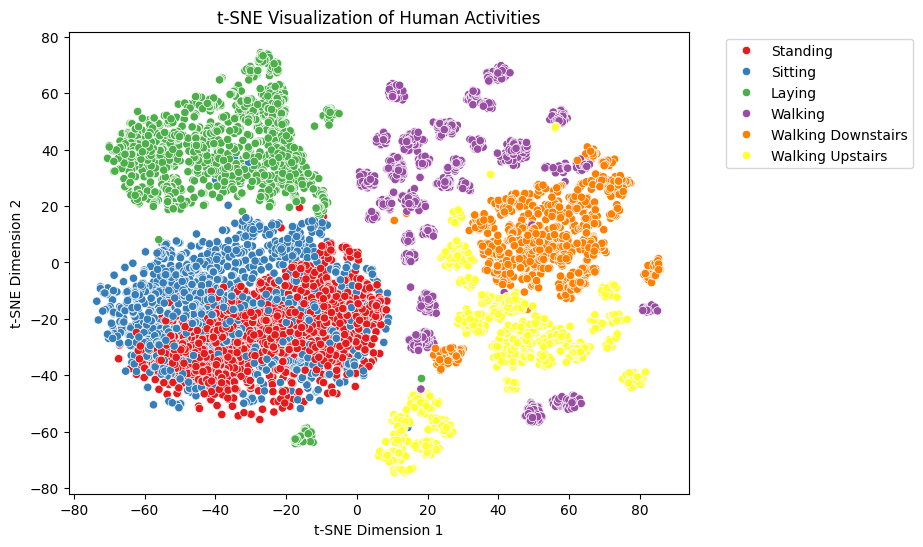

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Dim1",
    y="Dim2",
    hue="Activity",
    palette="Set1",
    data=tsne_df
)

plt.title("t-SNE Visualization of Human Activities")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.legend(bbox_to_anchor=(1.05,1))
plt.show()